In [6]:
from typing import Tuple
import os

import torch
import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.animation as animation

import matplotlib.cm as cm

import sys

sys.path.append('../..')


from muno.utils.data_utils import syncSuffle


plt.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'
plt.rcParams['savefig.bbox'] = 'tight'

# CMAP = "viridis" # RdBu_r # Reds
CMAP = cm.viridis
CMAP.set_bad('white')

def loadNcdfData(filename: str, dtype) -> Tuple[int, torch.Tensor]:
    with xr.open_dataset(filename) as dataSet: # '/media/mikemaslyaev/Data/Poseidon_data/CE_GAUSS/data_0.nc'
        try:
            data = torch.from_numpy(dataSet['data'].to_numpy()).to(dtype)
        except KeyError:
            data = torch.from_numpy(dataSet['velocity'].to_numpy()).to(dtype)
            
    data = data.swapaxes(1, 2)
    return data.shape[1], data

In [11]:
def pyplot_animate(array: torch.Tensor, comp: int = 0, location: str = None, title: str = '', t_val_max: int = 36,
                   mode: str = 'gif', name: str = ''):
    print(f'Shapes in input for pyplot_animate - {array.shape}')
    fig, ax = plt.subplots()
    arr_np = array.cpu().detach().numpy()[0, comp]

    norm_data = colors.Normalize(vmin=min(np.min(arr_np), -1e-4), 
                                 vmax=max(np.max(arr_np), 1e-4))
    
    current_directory = os.getcwd()

    img = arr_np[0, ...]

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    ax1.set_title('Field vis.')
    fig.suptitle(f'Component {comp+1}, time {0}')

    zero_thrs = 1e-6
    print(img.shape)
    im1 = ax1.imshow(img, norm=norm_data, cmap=CMAP, interpolation='bilinear')

    plt.colorbar(im1, ax=ax1, orientation='vertical')

    def update(frame):
        # mask_err = (torch.abs(ref_sol[comp, frame+1, ...]) > zero_thrs).detach().numpy()
        img = arr_np[frame, ...]

        im1.set_array(img)

        fig.suptitle(f'Component {comp+1}, time {frame}')

        return im1 #, im2 #fig, (ax1, ax2)

    ani = animation.FuncAnimation(fig=fig, func=update, frames=arr_np.shape[0], interval=90)

    if mode == 'gif':
        writer = animation.PillowWriter(fps=5, metadata=dict(artist='Me'), bitrate=1800)
        filename = f'component_{comp}_{name}.gif'
        ani.save(os.path.join(current_directory, location, filename), writer=writer, dpi = 300)
        print(f'saved as gif into {os.path.join(current_directory, location, filename)}')
    else:
        filename = f'component_{comp}_{name}.mp4'
        ani.save(os.path.join(current_directory, location, filename), dpi = 300)
        print(f'saved as mp4 into {os.path.join(current_directory, location, filename)}')

In [12]:
filepaths = ['/media/mikemaslyaev/Data/Poseidon_data/NS_SINES/velocity_0.nc',]
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_2.nc',
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_3.nc',
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_4.nc',
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_5.nc',
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_GAUSS/velocity_6.nc',
            #  '/media/mikemaslyaev/Data/Poseidon_data/NS_SINES/velocity_7.nc',]

print(f'Loading data from filepaths: {filepaths}')

params = {'t': {'L': 1., 'n': 128}, 'x': {'L': 1., 'n': 128}}

train_dataloaders = []
val_loaders       = []
data_processors   = []

for fidx, filepath in enumerate(filepaths):
    print(f'Loading dataset from {filepath}')
    sample_max = 1500

    channels, data = loadNcdfData(filepath, dtype = torch.float32)
    data = data[:sample_max]

    if channels == 3:
        cur_forcings = data[:, 2:]
        cur_solutions = data[:, :2]
    if channels == 5:
        cur_forcings = data[:, (0, 3, 4)]
        cur_solutions = data[:, (1, 2)]

    del data

    cur_solutions, cur_forcings = syncSuffle(cur_solutions, cur_forcings)

    train_max_idx = int(cur_solutions.shape[0] * 0.8)

    if fidx == 0:
        solutions_train = cur_solutions[:train_max_idx] # .swapaxes(-1, -2)
        forcings_train  = cur_forcings[:train_max_idx]  # .swapaxes(-1, -2)
    
        solutions_test  = cur_solutions[train_max_idx:] # .swapaxes(-1, -2)
        forcings_test   = cur_forcings[train_max_idx:]  # .swapaxes(-1, -2)
    else:
        solutions_train = torch.cat([solutions_train, cur_solutions[:train_max_idx],], dim = 0) # .swapaxes(-1, -2)
        forcings_train = torch.cat([forcings_train, cur_forcings[:train_max_idx],], dim = 0) # .swapaxes(-1, -2)

        solutions_test  = torch.cat([solutions_test, cur_solutions[train_max_idx:],], dim = 0) # .swapaxes(-1, -2)
        forcings_test  = torch.cat([forcings_test, cur_forcings[train_max_idx:],], dim = 0) # .swapaxes(-1, -2)
    print('Loaded!')

Loading data from filepaths: ['/media/mikemaslyaev/Data/Poseidon_data/NS_SINES/velocity_0.nc']
Loading dataset from /media/mikemaslyaev/Data/Poseidon_data/NS_SINES/velocity_0.nc
Loaded!


In [13]:
solutions_test.shape

torch.Size([236, 2, 21, 128, 128])

Shapes in input for pyplot_animate - torch.Size([1, 2, 21, 128, 128])
(128, 128)
saved as gif into /home/mikemaslyaev/Documents/FNOFound/experiments/pics/component_0_.gif


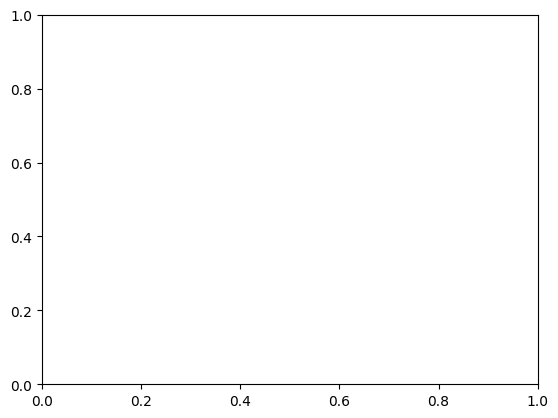

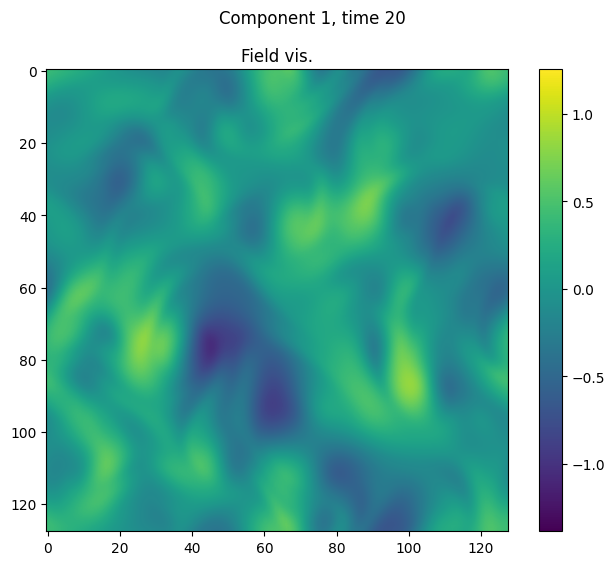

In [18]:
sample_idx = 25 

pyplot_animate(solutions_test[sample_idx:sample_idx+1, ...], comp = 0,
               location = '/home/mikemaslyaev/Documents/FNOFound/experiments/pics', title='NS_SINES_1st')

In [ ]:
rfftn_1 = np.fft.rfftn(solutions_test[0, 0, ...])
rfftn_2 = np.fft.rfftn(solutions_test[0, 1, ...])


In [20]:
from muno.utils.custom_trainer import Heatmap

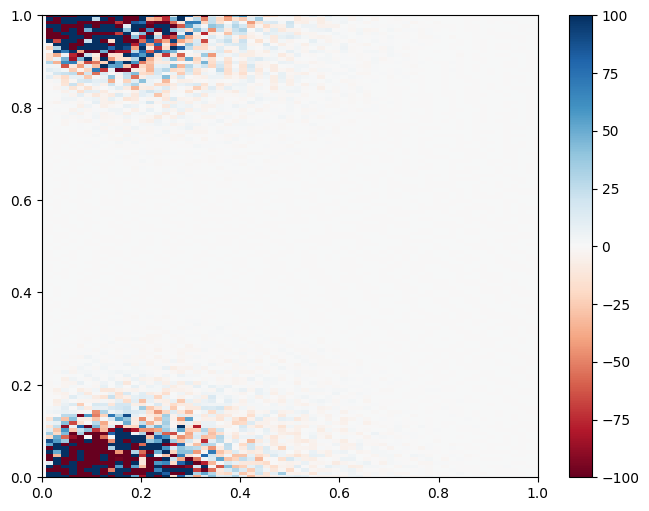

In [ ]:
Heatmap(rfftn_1[0, :, :].real, interval=[-100, 100]) # 

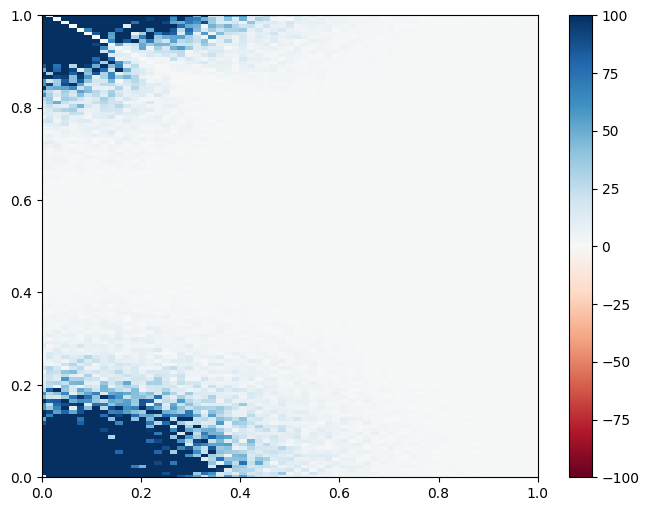

In [40]:
Heatmap(np.abs(rfftn_2[0, :, :] - rfftn_1[0, :, :]), interval=[-100, 100]) # 

In [1]:
import torch

In [5]:
0.1 < torch.inf; 1 < torch.inf

True

In [10]:
import datetime
time = datetime.datetime.now()
date = datetime.datetime.date(time)


In [13]:
date.month

4

In [15]:
import numpy as np

np.log10(18446744073692774399)/np.log10(1024)

6.399999999999869

In [1]:
index = 11
_data_lens = [10, 20, 30]
idxs = [index % dl for dl in _data_lens]

In [2]:
idxs

[1, 11, 11]